# agentv17_mcp_http_integration — LangGraph + MCP over HTTP/SSE

This version connects LangGraph to an MCP server running on a local port.

Architecture:

```text
LangGraph Agent → HTTP/SSE → MCP Server on localhost:8001
```

Start the server in a separate terminal before running the notebook.


## 1. Install dependencies

```bash
pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter mcp uvicorn
```


In [2]:
# Optional: uncomment in a fresh environment.
# %pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter mcp uvicorn


## 2. Start MCP HTTP/SSE server

Run this in a separate terminal from repo root:

```bash
python -m agentv17_mcp_http_integration.mcp_http_server
```

Expected server URL:

```text
http://127.0.0.1:8001/sse
```


## 3. Load environment variables


In [14]:
from pathlib import Path
import os
from dotenv import load_dotenv

cwd = Path.cwd()
load_dotenv(cwd / ".env")
load_dotenv(cwd.parent / ".env")

MCP_HTTP_URL = os.getenv("MCP_HTTP_URL", "http://127.0.0.1:8001/sse")

print("OpenAI API key present:", bool(os.getenv("OPENAI_API_KEY")))
print("LangSmith tracing:", os.getenv("LANGSMITH_TRACING"))
print("LangSmith project:", os.getenv("LANGSMITH_PROJECT"))
print("MCP HTTP URL:", MCP_HTTP_URL)


OpenAI API key present: True
LangSmith tracing: true
LangSmith project: langgraph-playground
MCP HTTP URL: http://127.0.0.1:8001/sse


## 4. Define state using NotRequired


In [15]:
from typing import NotRequired, TypedDict

class AgentState(TypedDict):
    input: str
    plan: NotRequired[str]
    metrics_context: NotRequired[str]
    runbook_context: NotRequired[str]
    final_answer: NotRequired[str]


## 5. Define MCP HTTP client helper


In [16]:
from mcp import ClientSession
from mcp.client.sse import sse_client

async def call_mcp_http_tool(tool_name: str, arguments: dict) -> str:
    async with sse_client(MCP_HTTP_URL) as (read, write):
        async with ClientSession(read, write) as session:
            await session.initialize()
            result = await session.call_tool(tool_name, arguments=arguments)

    return "\n".join(
        item.text for item in result.content if getattr(item, "type", None) == "text"
    )


## 6. Test MCP HTTP tools directly


In [17]:
metrics = await call_mcp_http_tool(
    "get_epp_metrics",
    {"issue": "CHECK-DOMAIN timeout after R13"},
)

runbook = await call_mcp_http_tool(
    "get_epp_runbook",
    {"issue": "CHECK-DOMAIN timeout after R13"},
)

print(metrics)
print()
print(runbook)


EPP Metrics: CHECK-DOMAIN p95 response_time is 240 ms after R13. CONNECTION_TIMEOUT failure volume increased for client_b during peak hours. Investigation issue: CHECK-DOMAIN timeout after R13

Runbook Guidance: For CHECK-DOMAIN timeout spikes, inspect upstream registry connectivity, DNS resolver latency, registry endpoint health, and connection pool saturation. Rollback if timeout volume remains above baseline for two consecutive hours. Investigation issue: CHECK-DOMAIN timeout after R13


## 7. Define LangGraph async nodes


In [18]:
import asyncio
from langchain_openai import ChatOpenAI

async def planner_node(state: AgentState) -> AgentState:
    return {
        "plan": (
            "Plan: call MCP HTTP metrics tool and MCP HTTP runbook tool in parallel, "
            "then synthesize the incident analysis."
        )
    }

async def mcp_http_tools_node(state: AgentState) -> AgentState:
    metrics_task = call_mcp_http_tool("get_epp_metrics", {"issue": state["input"]})
    runbook_task = call_mcp_http_tool("get_epp_runbook", {"issue": state["input"]})

    metrics_context, runbook_context = await asyncio.gather(
        metrics_task,
        runbook_task,
    )

    return {
        "metrics_context": metrics_context,
        "runbook_context": runbook_context,
    }

async def summarize_node(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    prompt = f'''
User request:
{state["input"]}

Plan:
{state["plan"]}

MCP HTTP metrics context:
{state["metrics_context"]}

MCP HTTP runbook context:
{state["runbook_context"]}

Write a concise incident analysis with:
1. likely cause
2. supporting evidence
3. recommended next action
'''

    response = await llm.ainvoke(prompt)
    return {"final_answer": response.content}


## 8. Build graph


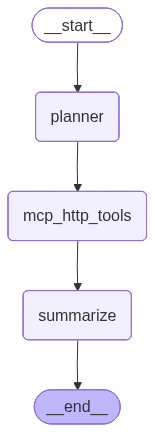

In [19]:
from langgraph.graph import START, END, StateGraph

def build_graph():
    graph_builder = StateGraph(AgentState)

    graph_builder.add_node("planner", planner_node)
    graph_builder.add_node("mcp_http_tools", mcp_http_tools_node)
    graph_builder.add_node("summarize", summarize_node)

    graph_builder.add_edge(START, "planner")
    graph_builder.add_edge("planner", "mcp_http_tools")
    graph_builder.add_edge("mcp_http_tools", "summarize")
    graph_builder.add_edge("summarize", END)

    return graph_builder.compile()

graph = build_graph()
graph


## 9. Visualize graph


In [20]:
print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	planner(planner)
	mcp_http_tools(mcp_http_tools)
	summarize(summarize)
	__end__([<p>__end__</p>]):::last
	__start__ --> planner;
	mcp_http_tools --> summarize;
	planner --> mcp_http_tools;
	summarize --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 10. Visualize PNG


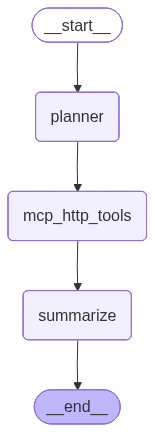

In [21]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("PNG rendering failed:", e)


## 11. Run MCP HTTP graph


In [22]:
result = await graph.ainvoke({
    "input": "Investigate CHECK-DOMAIN timeout issue after release R13."
})

print(result["final_answer"])


### Incident Analysis: CHECK-DOMAIN Timeout Issue After Release R13

#### 1. Likely Cause
The increase in CONNECTION_TIMEOUT failures for CHECK-DOMAIN after release R13 is likely due to a combination of factors affecting upstream registry connectivity and DNS resolver latency. The observed p95 response time of 240 ms indicates that the service is experiencing delays, which may be exacerbated during peak hours when client_b is active.

#### 2. Supporting Evidence
- **EPP Metrics**: The p95 response time for CHECK-DOMAIN has risen to 240 ms post-R13, indicating a significant degradation in performance.
- **Failure Volume**: There is a noted increase in CONNECTION_TIMEOUT failures specifically for client_b during peak hours, suggesting that the issue is not uniformly distributed and may be related to specific load conditions or client behavior.
- **Runbook Guidance**: The runbook suggests inspecting upstream registry connectivity and DNS resolver latency, both of which are critical for th

## 12. Inspect MCP contexts


In [23]:
print("METRICS CONTEXT:")
print(result["metrics_context"])
print()
print("RUNBOOK CONTEXT:")
print(result["runbook_context"])


METRICS CONTEXT:
EPP Metrics: CHECK-DOMAIN p95 response_time is 240 ms after R13. CONNECTION_TIMEOUT failure volume increased for client_b during peak hours. Investigation issue: Investigate CHECK-DOMAIN timeout issue after release R13.

RUNBOOK CONTEXT:
Runbook Guidance: For CHECK-DOMAIN timeout spikes, inspect upstream registry connectivity, DNS resolver latency, registry endpoint health, and connection pool saturation. Rollback if timeout volume remains above baseline for two consecutive hours. Investigation issue: Investigate CHECK-DOMAIN timeout issue after release R13.


## 13. Stream async graph updates


In [24]:
async for chunk in graph.astream(
    {"input": "Investigate CHECK-DOMAIN timeout issue after release R13."},
    stream_mode="updates",
):
    print("\n--- update ---")
    print(chunk)



--- update ---
{'planner': {'plan': 'Plan: call MCP HTTP metrics tool and MCP HTTP runbook tool in parallel, then synthesize the incident analysis.'}}

--- update ---
{'mcp_http_tools': {'metrics_context': 'EPP Metrics: CHECK-DOMAIN p95 response_time is 240 ms after R13. CONNECTION_TIMEOUT failure volume increased for client_b during peak hours. Investigation issue: Investigate CHECK-DOMAIN timeout issue after release R13.', 'runbook_context': 'Runbook Guidance: For CHECK-DOMAIN timeout spikes, inspect upstream registry connectivity, DNS resolver latency, registry endpoint health, and connection pool saturation. Rollback if timeout volume remains above baseline for two consecutive hours. Investigation issue: Investigate CHECK-DOMAIN timeout issue after release R13.'}}

--- update ---
{'summarize': {'final_answer': '### Incident Analysis: CHECK-DOMAIN Timeout Issue After Release R13\n\n#### 1. Likely Cause\nThe increase in CONNECTION_TIMEOUT failures for CHECK-DOMAIN after release R13 

## 14. Key comparison

Stdio MCP:

```text
agent starts local subprocess
```

HTTP/SSE MCP:

```text
server runs separately on a port
agent connects over HTTP/SSE
```

The HTTP/SSE pattern is closer to production service architecture.
